# Building and manipulating atomic structures

This notebook follows the [official ASE Manipulating Atoms tutorial](https://docs.ase-lib.org/examples_generated/01-gettingstarted/03-manipulating-atoms.html). It uses two examples to demonstrate common `Atoms` operations: constructing an Ag/Ni surface model and assembling a water layer on a Ni(111) slab.

The emphasis is geometric construction rather than energy evaluation or relaxation. Positions, cell lengths, vacuum sizes, and offsets are given in ångström (Å).

## Building an Ag adatom model on Ni

The value `a = 3.55` Å is the chosen bulk Ni lattice constant. The six cell parameters specify three vector lengths followed by the angles between them. Here, the in-plane vectors have length `sqrt(2) * a` and enclose 120°, forming a four-atom hexagonal surface cell. Periodicity is enabled along `x` and `y` but disabled along `z`.

The rows in `scaled_positions` are fractional coordinates relative to the cell vectors. `center(vacuum=5.0, axis=2)` expands the cell to 10 Å along `z` and centers the Ni layer at `z = 5` Å, leaving 5 Å of vacuum on each side.

The printed `Cell` exposes the three Cartesian cell vectors, and `atoms.positions` converts the fractional input to Cartesian coordinates. A negative `x` coordinate is expected for atoms translated along the skewed second cell vector. Indexing the collection with `atoms[0]` returns the first Ni atom together with its position and index.

In [1]:
from math import sqrt

from ase import Atoms

a = 3.55
atoms = Atoms(
    'Ni4',
    cell=[sqrt(2) * a, sqrt(2) * a, 1.0, 90, 90, 120],
    pbc=(1, 1, 0),
    scaled_positions=[(0, 0, 0), (0.5, 0, 0), (0, 0.5, 0), (0.5, 0.5, 0)],
)
atoms.center(vacuum=5.0, axis=2)

In [2]:
print(atoms.cell)

Cell([[5.020458146424487, 0.0, 0.0], [-2.5102290732122428, 4.347844293440141, 0.0], [0.0, 0.0, 10.0]])


In [3]:
print(atoms.positions)

[[ 0.          0.          5.        ]
 [ 2.51022907  0.          5.        ]
 [-1.25511454  2.17392215  5.        ]
 [ 1.25511454  2.17392215  5.        ]]


In [4]:
print(atoms[0])

Atom('Ni', [np.float64(0.0), np.float64(0.0), np.float64(5.0)], index=0)


## Saving and visualizing the surface

`atoms.write()` exports the structure to `slab.xyz`. `view(atoms)` launches ASE's interactive desktop viewer; the displayed `Popen` value is only the handle for that separate GUI process.

`plot_atoms()` instead creates a static Matplotlib projection. The `-80x,0y,0z` rotation selects a side view of the slab and vacuum region without changing the stored atomic coordinates.

In [5]:
from ase.visualize import view
atoms.write('../files/tutorial_04/slab.xyz')
view(atoms)

<Popen: returncode: None args: ['/Users/liangze/Desktop/Experiences/ase_lear...>

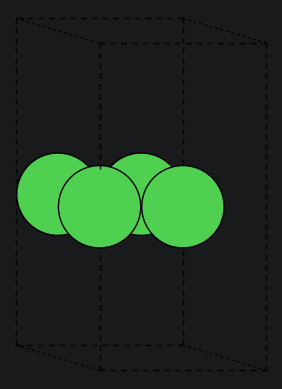

In [6]:
import matplotlib.pyplot as plt

from ase.visualize.plot import plot_atoms

fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation=('-80x,0y,0z'))
ax.set_axis_off()

## Repeating a structure

`atoms.repeat((3, 3, 2))` returns a new supercell containing translated copies of the original structure: three along each in-plane cell vector and two along `z`. The original object is unchanged. Starting from four Ni atoms, the repeated object contains

$$
4 × 3 × 3 × 2 = 72\ \text{atoms}.
$$

Repeating along `z` creates geometric copies even though that direction is non-periodic; it does not enable periodic boundary conditions.

In [7]:
atoms_repeated = atoms.repeat((3, 3, 2))

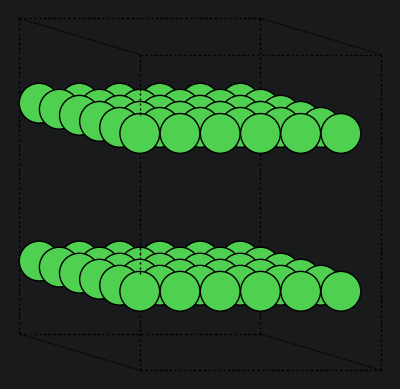

In [8]:
fig, ax = plt.subplots()
plot_atoms(atoms_repeated, ax, rotation=('-80x,0y,0z'))
ax.set_axis_off()

## Adding an Ag adatom

The Ag atom is placed 1.9 Å above a three-fold hollow site. ASE stores positions in Cartesian coordinates, so the fractional site `relative = (1/6, 1/6, 0.5)` is converted using the cell vectors:

$$
r = s_1 a_1 + s_2 a_2 + s_3 a_3 + (0, 0, h).
$$

The `s_3 = 0.5` component locates the centered Ni plane, and the final term raises the adatom by `h = 1.9` Å. `append('Ag')` adds the new atom at the end of the collection, after which `atoms.positions[-1]` assigns its calculated position.

In [9]:
import numpy as np

h = 1.9
relative = (1 / 6, 1 / 6, 0.5)
absolute = np.dot(relative, atoms.cell) + (0, 0, h)
atoms.append('Ag')
atoms.positions[-1] = absolute

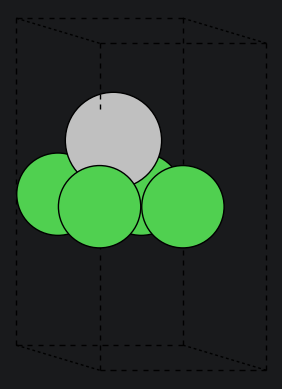

In [10]:
fig, ax = plt.subplots()
plot_atoms(atoms, ax, rotation=('-80x,0y,0z'))
ax.set_axis_off()

## Building a water–Ni interface

The second workflow combines a periodic water layer with a Ni(111) slab. The two in-plane cells are first oriented and matched, the water layer is placed above the surface, and the combined 36-atom structure is saved as a starting model. No calculator or optimizer is used, so the final separation and strained geometry have not been energetically relaxed.

### Defining and saving the water layer

The `p` array has shape 12 × 3 and contains Cartesian coordinates for four water molecules. `Atoms('4(OH2)')` assigns four oxygen and eight hydrogen symbols to those rows. The diagonal 3 × 3 array `c` defines an 8.490373 Å by 4.901919 Å in-plane cell with 26.93236 Å along `z`; periodicity is enabled only in the two in-plane directions.

The ASE trajectory format preserves the structure, cell, and boundary conditions in `water.traj`. Reading it back demonstrates that the saved object can be reconstructed before plotting, and the printed cell confirms its three lengths.

In [11]:
import numpy as np

from ase import Atoms

p = np.array(
    [
        [0.27802511, -0.07732213, 13.46649107],
        [0.91833251, -1.02565868, 13.41456626],
        [0.91865997, 0.87076761, 13.41228287],
        [1.85572027, 2.37336781, 13.56440907],
        [3.13987926, 2.3633134, 13.4327577],
        [1.77566079, 2.37150862, 14.66528237],
        [4.52240322, 2.35264513, 13.37435864],
        [5.16892729, 1.40357034, 13.42661052],
        [5.15567324, 3.30068395, 13.4305779],
        [6.10183518, -0.0738656, 13.27945071],
        [7.3856151, -0.07438536, 13.40814585],
        [6.01881192, -0.08627583, 12.1789428],
    ]
)
c = np.array([[8.490373, 0.0, 0.0], [0.0, 4.901919, 0.0], [0.0, 0.0, 26.93236]])
water = Atoms('4(OH2)', positions=p, cell=c, pbc=[1, 1, 0])
water.write('../files/tutorial_04/water.traj')

In [12]:
from ase.io import read

water = read('../files/tutorial_04/water.traj')

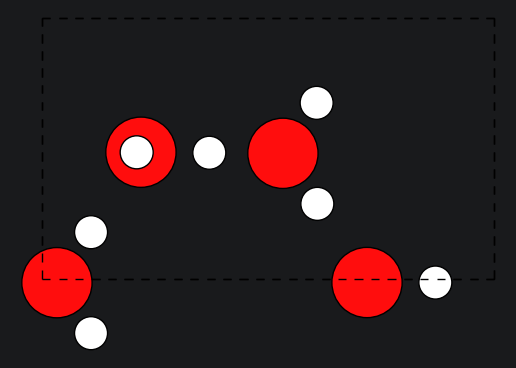

In [13]:
fig, ax = plt.subplots()
plot_atoms(water, ax)
ax.set_axis_off()

In [14]:
print(water.cell)

Cell([8.490373, 4.901919, 26.93236])


### Creating a matching Ni(111) slab

`fcc111()` builds a three-layer Ni(111) slab using the same 3.55 Å bulk lattice constant. `size=[2, 4, 3]` gives two and four surface repeats with three atomic layers, for 24 Ni atoms, while `orthogonal=True` produces perpendicular in-plane cell vectors.

No vacuum is added at this stage, so the printed third cell vector has zero length. The in-plane lengths, approximately 5.020 Å and 8.696 Å, are close to the water cell lengths after they are exchanged by a 90° in-plane reorientation.

Cell([5.020458146424487, 8.695688586880282, 0.0])


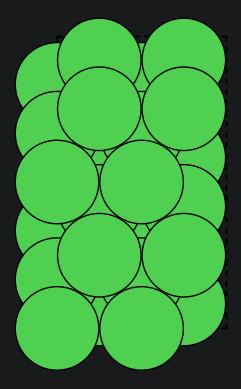

In [15]:
from ase.build import fcc111

slab = fcc111('Ni', size=[2, 4, 3], a=3.55, orthogonal=True)

fig, ax = plt.subplots()
plot_atoms(slab, ax)
ax.set_axis_off()

print(slab.cell)

### Aligning and matching the water layer

Assigning `water.cell` exchanges the two in-plane cell lengths, but it does not rotate or rescale the existing Cartesian positions. `water.rotate(90, 'z', center=(0, 0, 0))` therefore rotates the molecules separately about the origin. Because the layer is periodic along `x` and `y`, `water.wrap()` then maps atoms back into the primary periodic image.

`water.set_cell(slab.cell, scale_atoms=True)` changes the water cell to match the slab and rescales the atomic positions so their fractional coordinates are retained. This applies an in-plane strain of about 2.4%, reflecting the lattice mismatch between the two starting cells.

Finally, `zmin` and `zmax` identify the lowest water atom and highest Ni atom. Translating the water layer by `zmax - zmin + 1.5` places its lowest atom 1.5 Å above the surface.

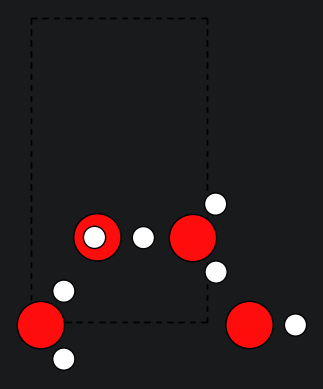

In [16]:
water.cell = [water.cell[1, 1], water.cell[0, 0], 0.0]

fig, ax = plt.subplots()
plot_atoms(water, ax)
ax.set_axis_off()

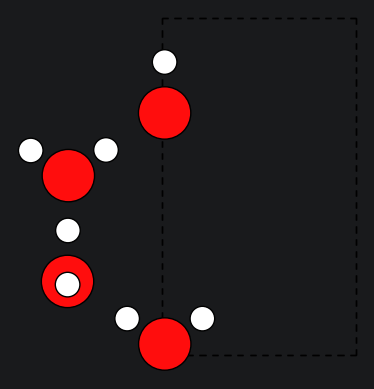

In [17]:
water.rotate(90, 'z', center=(0, 0, 0))

fig, ax = plt.subplots()
plot_atoms(water, ax)
ax.set_axis_off()

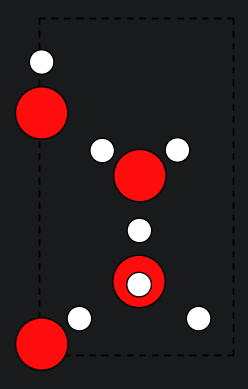

In [18]:
water.wrap()
fig, ax = plt.subplots()
plot_atoms(water, ax)
ax.set_axis_off()

In [19]:
water.set_cell(slab.cell, scale_atoms=True)
zmin = water.positions[:, 2].min()
zmax = slab.positions[:, 2].max()
water.positions += (0, 0, zmax - zmin + 1.5)

### Combining, centering, and saving the interface

Adding two `Atoms` objects concatenates their atoms while taking the cell and periodic-boundary settings from the first object, `slab`. The resulting interface contains 24 Ni atoms and 12 water-layer atoms.

`interface.center(vacuum=6, axis=2)` creates the out-of-plane cell dimension and leaves 6 Å of vacuum on both sides of the complete interface. The structure is written to `NiH2O.traj` and plotted as a final geometry check.

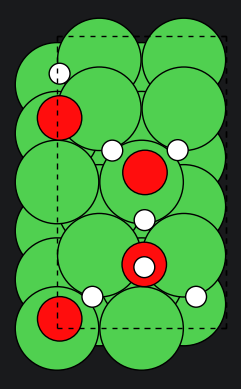

In [20]:
interface = slab + water
interface.center(vacuum=6, axis=2)
interface.write('../files/tutorial_04/NiH2O.traj')

fig, ax = plt.subplots()
plot_atoms(interface, ax)
ax.set_axis_off()

## Takeaways and possible extensions

This notebook distinguishes fractional coordinates from Cartesian positions and shows how cell operations, periodic wrapping, repetition, rotation, translation, and `Atoms` addition affect a structure. Plotting after each major transformation makes cell-orientation mistakes and unintended overlaps easier to detect.

Useful next steps include checking interatomic distances after assembly, varying the initial water–surface separation, testing larger commensurate cells to reduce lattice strain, adding constraints to the deeper Ni layers, and relaxing the interface with an appropriate calculator. Any quantitative interface study should converge the slab thickness, lateral cell size, vacuum, and strain.